In [21]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import pickle
from config.settings import ROOT_DIR, DATA_PATH_X_train_BALANCED, DATA_PATH_y_train_BALANCED, DATA_PATH_X_test, DATA_PATH_y_test
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
X_train = pd.read_parquet(DATA_PATH_X_train_BALANCED)
X_temp = pd.read_parquet(DATA_PATH_X_test)
y_train = pd.read_parquet(DATA_PATH_y_train_BALANCED)
y_temp = pd.read_parquet(DATA_PATH_y_test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [3]:
X_train.columns = [f'X{i}' for i in range(1, len(X_train.columns)+1)]
X_val.columns = [f'X{i}' for i in range(1, len(X_train.columns)+1)]
X_test.columns = [f'X{i}' for i in range(1, len(X_train.columns)+1)]

In [5]:
models_params = {
    'Logistic Regression': (LogisticRegression(random_state=42), {}),
    'KNN': (KNeighborsClassifier(), {'classifier__n_neighbors': [10, 15, 20, 25, 30]}),
    'DecisionTreeClassifier': (DecisionTreeClassifier(random_state=42),{'classifier__max_depth': [5, 10, 15]}),
    'RandomForestClassifier': (RandomForestClassifier(random_state=42), {'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [5, 10, 15]}),
    'GradientBoostingClassifier': (GradientBoostingClassifier(random_state=42), {'classifier__learning_rate': [0.1, 0.01, 0.001]}),
    'AdaBoostClassifier': (AdaBoostClassifier(random_state=42), {'classifier__n_estimators': [50, 100, 200]}),
    'XGBClassifier': (XGBClassifier(random_state=42), {'classifier__max_depth': [3, 4, 5]}),
    'Naive Bayes': (GaussianNB(), {})
}

In [9]:
best_overall_model = None
best_auc = 0
results = []

In [10]:
for name, (model, params) in models_params.items():
    print(f"\n{'='*40}\n{name}\n{'='*40}")
    
    # Pipeline
    full_pipeline = ImbPipeline(steps=[
        ('classifier', model)
    ])
    
    # GridSearchCV para ajuste de hiperparámetros al mejor auc
    cv_strategy = StratifiedKFold(n_splits=5)
    grid_search = GridSearchCV(
        full_pipeline, 
        param_grid=params, 
        cv=cv_strategy, 
        scoring='roc_auc',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_model_pipeline = grid_search.best_estimator_
    
    # 4. Evaluación de Estabilidad (Val vs Test)
    y_val_pred = best_model_pipeline.predict(X_val)
    y_test_pred = best_model_pipeline.predict(X_test)
    
    auc_val = roc_auc_score(y_val, best_model_pipeline.predict_proba(X_val)[:, 1])
    auc_test = roc_auc_score(y_test, best_model_pipeline.predict_proba(X_test)[:, 1])
    
    print(f"Mejores Parámetros: {grid_search.best_params_}")
    print(f"AUC Validación: {auc_val:.4f}")
    print(f"AUC Prueba: {auc_test:.4f}")
    print(f"Diferencia (Estabilidad): {abs(auc_val - auc_test):.4f}")
    
    # Reporte detallado
    print("\n--- Reporte de Prueba ---")
    print(classification_report(y_test, y_test_pred))
    
    # Guardar el mejor modelo global basado en AUC de prueba
    if auc_val > best_auc:
        best_auc = auc_val
        best_overall_model = best_model_pipeline
        best_model_name = name

# 5. Visualización del mejor modelo final
print(f"\nMejor Modelo: {best_model_name} con AUC {best_auc:.4f}")


Logistic Regression
Mejores Parámetros: {}
AUC Validación: 0.9224
AUC Prueba: 0.9201
Diferencia (Estabilidad): 0.0023

--- Reporte de Prueba ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     81149
           1       0.64      0.72      0.68      7589

    accuracy                           0.94     88738
   macro avg       0.81      0.84      0.82     88738
weighted avg       0.94      0.94      0.94     88738


KNN
Mejores Parámetros: {'classifier__n_neighbors': 30}
AUC Validación: 0.8511
AUC Prueba: 0.8549
Diferencia (Estabilidad): 0.0039

--- Reporte de Prueba ---
              precision    recall  f1-score   support

           0       0.96      0.90      0.93     81149
           1       0.37      0.64      0.47      7589

    accuracy                           0.87     88738
   macro avg       0.66      0.77      0.70     88738
weighted avg       0.91      0.87      0.89     88738


DecisionTreeClassifier
Mejores Parámetro

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     81149
           1       0.61      0.78      0.68      7589

    accuracy                           0.94     88738
   macro avg       0.79      0.87      0.83     88738
weighted avg       0.95      0.94      0.94     88738

              precision    recall  f1-score   support

           0       0.98      0.95      0.97     81149
           1       0.61      0.78      0.68      7589

    accuracy                           0.94     88738
   macro avg       0.79      0.87      0.83     88738
weighted avg       0.95      0.94      0.94     88738



Text(0.5, 1.0, 'Curva ROC: Prueba')

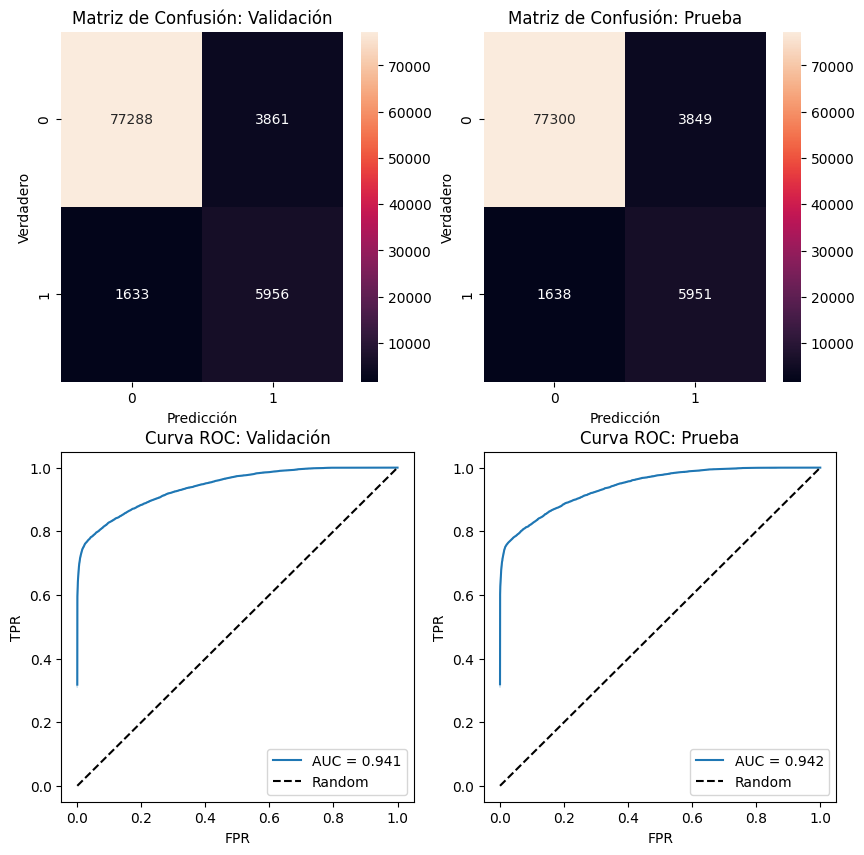

In [13]:
pipeline_final = ImbPipeline(steps=[
        ('classifier', XGBClassifier(random_state=42))
    ])
pipeline_final.fit(X_train, y_train)

y_val_pred = pipeline_final.predict(X_val)
y_test_pred = pipeline_final.predict(X_test)

auc_val = roc_auc_score(y_val, pipeline_final.predict_proba(X_val)[:, 1])
auc_test = roc_auc_score(y_test, pipeline_final.predict_proba(X_test)[:, 1])

print(classification_report(y_val, y_val_pred))
print(classification_report(y_test, y_test_pred))

fig, axes = plt.subplots(2,2, figsize=(10, 10))
sns.heatmap(confusion_matrix(y_val,pipeline_final.predict(X_val)),annot=True,fmt="d", ax = axes[0,0])
sns.heatmap(confusion_matrix(y_test,pipeline_final.predict(X_test)),annot=True,fmt="d", ax = axes[0,1])

fpr_val, tpr_val, thresholds = roc_curve(y_val, pipeline_final.predict_proba(X_val)[:, 1])
fpr_test, tpr_test, thresholds = roc_curve(y_test, pipeline_final.predict_proba(X_test)[:, 1])

roc_df_val = pd.DataFrame({'FPR': fpr_val,'TPR': tpr_val})
roc_df_test = pd.DataFrame({'FPR': fpr_test,'TPR': tpr_test})

sns.lineplot(data=roc_df_val, x = 'FPR', y = 'TPR', label = f"AUC = {auc_val:.3f}", ax = axes[1,0])
sns.lineplot(x = [0,1], y = [0,1], linestyle = '--', color = 'black', label = 'Random', ax = axes[1,0])
sns.lineplot(data=roc_df_test, x = 'FPR', y = 'TPR', label = f"AUC = {auc_test:.3f}", ax = axes[1,1])
sns.lineplot(x = [0,1], y = [0,1], linestyle = '--', color = 'black', label = 'Random', ax = axes[1,1])

axes[0,0].set_ylabel("Verdadero")
axes[0,1].set_ylabel("Verdadero")
axes[0,0].set_xlabel("Predicción")
axes[0,1].set_xlabel("Predicción")

axes[0,0].set_title("Matriz de Confusión: Validación")
axes[0,1].set_title("Matriz de Confusión: Prueba")
axes[1,0].set_title("Curva ROC: Validación")
axes[1,1].set_title("Curva ROC: Prueba")


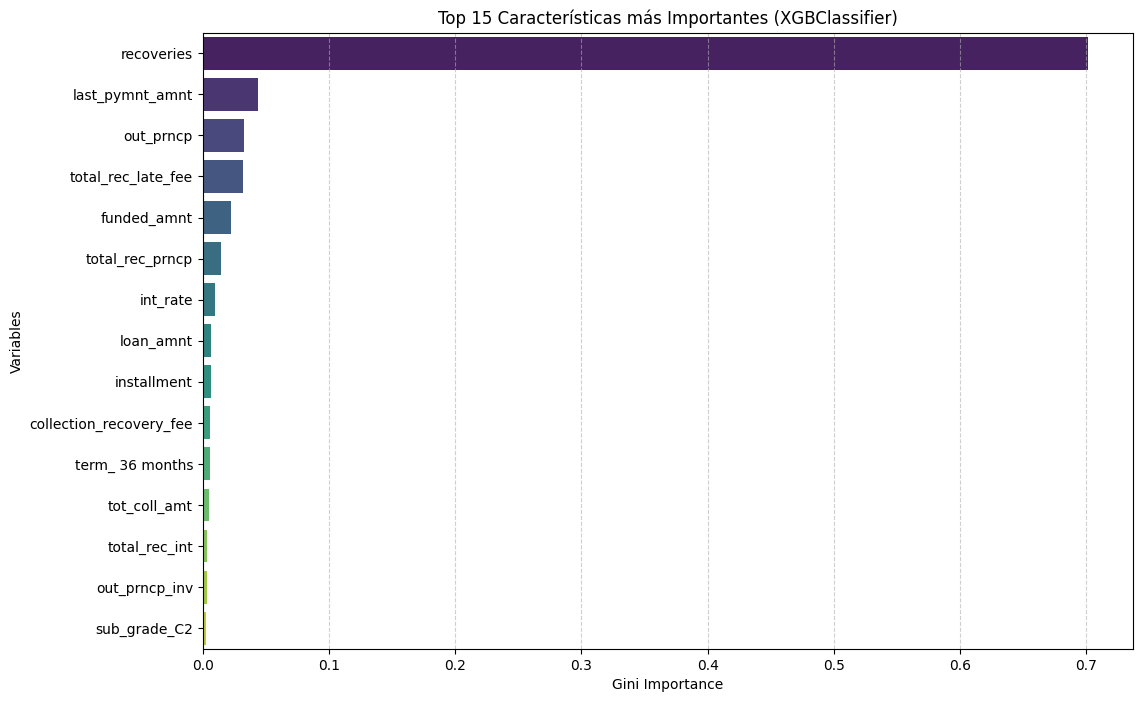

In [18]:
# 1. Extraer el modelo y los nombres de las columnas
final_rf = pipeline_final.named_steps['classifier']
#preprocessor = pipeline_final.named_steps['preprocessor']

# Obtener nombres de columnas (manejando transformaciones)
#cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out()
#num_features = preprocessor.named_transformers_['num'].get_feature_names_out()
original_cols = (pd.read_parquet(DATA_PATH_X_train_BALANCED)).columns
all_features = original_cols#list(num_features) + list(cat_features)

# 2. Crear el DataFrame de importancia
rf_importances = pd.DataFrame({
    'Feature': all_features,
    'Importance': final_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importances.head(15), palette='viridis')
plt.title('Top 15 Características más Importantes (XGBClassifier)')
plt.xlabel('Gini Importance')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [22]:
MODEL_PATH = ROOT_DIR / "models/model.pkl"
with open(MODEL_PATH, 'wb') as file:
    pickle.dump(pipeline_final, file)